# Smart Healthcare Prediction System using Machine Learning
This notebook demonstrates a complete beginner-friendly workflow:
1. Import libraries
2. Load and inspect data
3. Clean data (duplicates + missing values)
4. Filter rows with age > 40
5. Perform correlation analysis
6. Train Logistic Regression
7. Predict output and visualize with a heatmap

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Dataset
Read the healthcare dataset from the `data` folder and check its shape.

In [2]:
# Load dataset
df = pd.read_csv('../data/healthcare.csv')
print('Dataset loaded successfully.')
print('Shape:', df.shape)

Dataset loaded successfully.
Shape: (20, 5)


## Display First Few Rows
View the first 5 records to understand data structure and values.

In [3]:
# Show top rows
df.head()

,age,cholesterol,bp,heart_rate,target
0,45,230.0,140.0,85.0,1
1,52,250.0,150.0,88.0,1
2,36,190.0,120.0,72.0,0
3,60,270.0,160.0,95.0,1
4,48,210.0,130.0,80.0,0


## Data Cleaning
This step removes duplicate rows and fills missing numeric values with the column mean.

In [4]:
# Remove duplicates
print('Rows before cleaning:', len(df))
df = df.drop_duplicates().copy()
print('Rows after removing duplicates:', len(df))

# Fill NaN values with mean
numeric_cols = ['age', 'cholesterol', 'bp', 'heart_rate']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print('Missing values after cleaning:')
print(df.isna().sum())

Rows before cleaning: 20
Rows after removing duplicates: 19
Missing values after cleaning:
age            0
cholesterol    0
bp             0
heart_rate     0
target         0
dtype: int64


## Data Filtering
Filter the dataset to keep records where age is greater than 40.

In [5]:
# Apply filter for age > 40
filtered_df = df[df['age'] > 40].copy()
print('Filtered dataset shape (age > 40):', filtered_df.shape)
filtered_df.head()

Filtered dataset shape (age > 40): (16, 5)


,age,cholesterol,bp,heart_rate,target
0,45,230.0,140.0,85.0,1
1,52,250.0,150.0,88.0,1
3,60,270.0,160.0,95.0,1
4,48,210.0,130.0,80.0,0
5,55,240.0,145.0,90.0,1


## Correlation Analysis
Compute the correlation matrix to understand relationships between variables.

In [6]:
# Correlation matrix
corr_matrix = filtered_df.corr(numeric_only=True)
print('Correlation matrix:')
print(corr_matrix)

Correlation matrix:
                  age  cholesterol        bp  heart_rate    target
age          1.000000     0.925764  0.934191    0.847521  0.700683
cholesterol  0.925764     1.000000  0.941716    0.817408  0.710945
bp           0.934191     0.941716  1.000000    0.852683  0.654426
heart_rate   0.847521     0.817408  0.852683    1.000000  0.717817
target       0.700683     0.710945  0.654426    0.717817  1.000000


## Build Logistic Regression Model
Split the data into train and test sets, train the model, and evaluate accuracy.

In [7]:
# Define features and target
X = filtered_df[['age', 'cholesterol', 'bp', 'heart_rate']]
y = filtered_df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Model trained successfully.')
print(f'Test Accuracy: {accuracy:.2f}')

Model trained successfully.
Test Accuracy: 1.00


## Predict Output for a Sample Input
Use the trained model to predict the target for a new patient input.

In [8]:
# Sample prediction
sample_input = [[50, 220, 130, 80]]
sample_prediction = model.predict(sample_input)[0]
print('Sample input:', sample_input[0])
print('Predicted target:', sample_prediction)

Sample input: [50, 220, 130, 80]
Predicted target: 1


c:\Users\dellb\OneDrive\Desktop\FDS PROJECT\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Heatmap Visualization
Visualize the correlation matrix with a heatmap for easier interpretation.

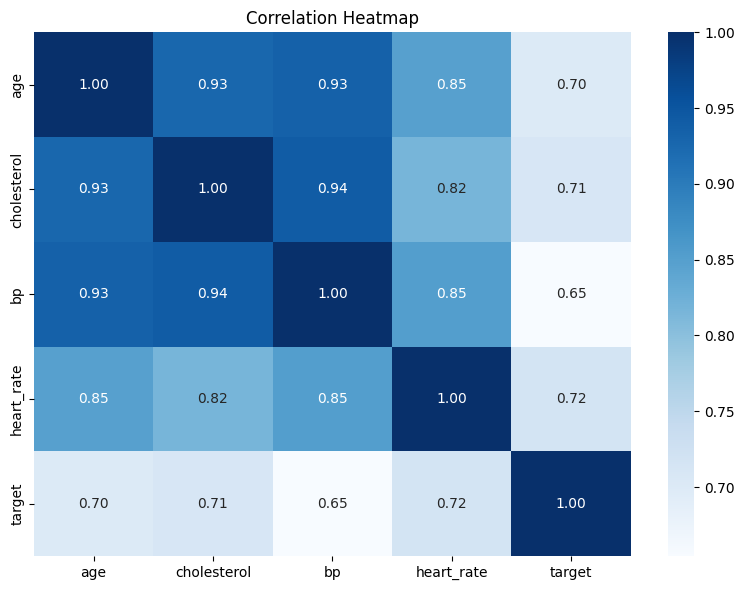

Correlation heatmap generated.


In [9]:
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print('Correlation heatmap generated.')